# Collatz Conjecture — Basic Exploration

Reproduce known results to validate our toolkit.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from collatz.core import syracuse
from collatz.visualize import plot_stopping_times, plot_trajectory, plot_v_sequence_histogram

## Famous trajectories
27 is the smallest number with a surprisingly long trajectory (111 steps, peak 9232).

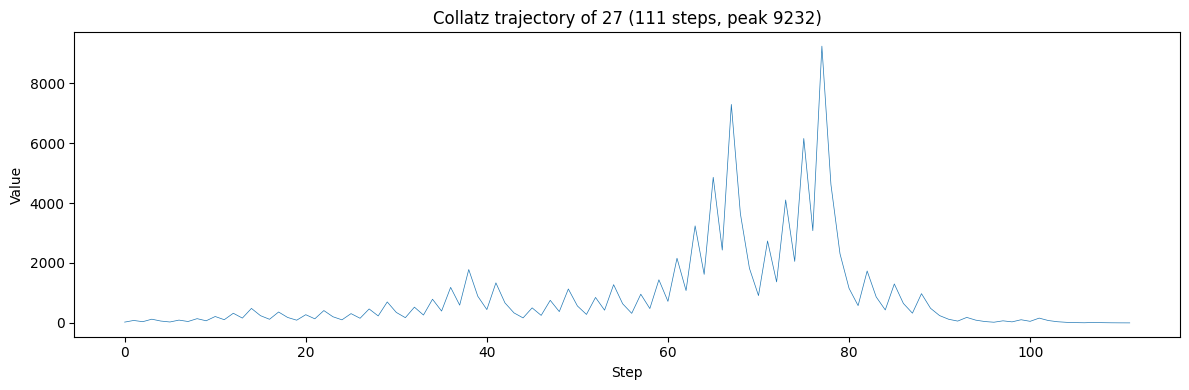

In [2]:
plot_trajectory(27)
plt.tight_layout()
plt.show()

## Stopping time distribution for n = 1..100,000

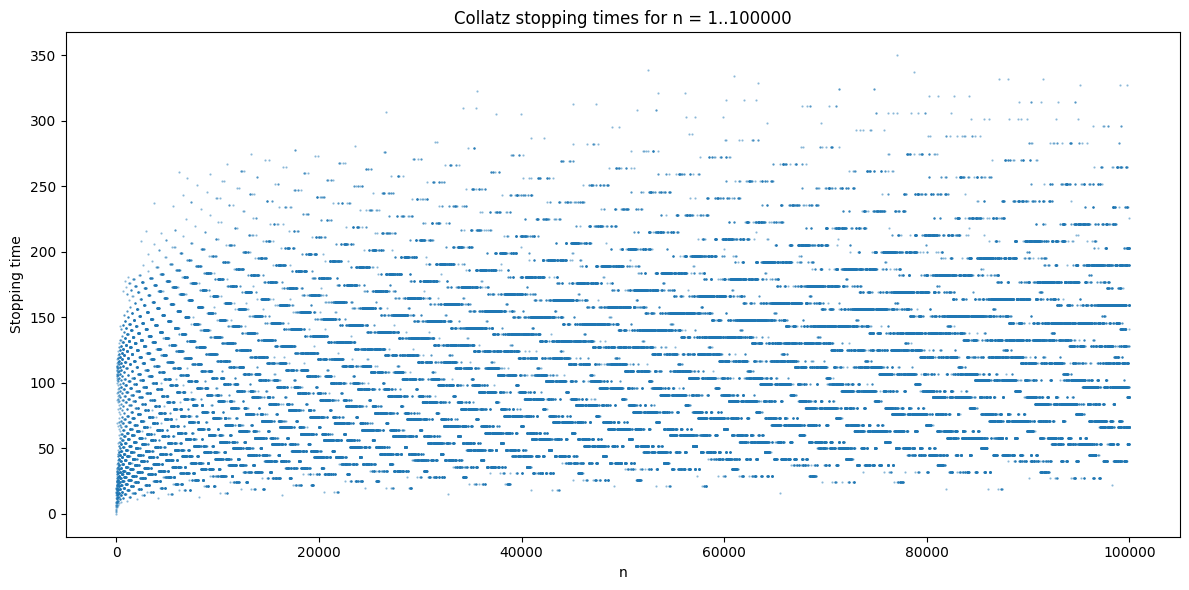

In [3]:
plot_stopping_times(1, 100_000)
plt.tight_layout()
plt.show()

## v-value distribution

If Collatz steps were random, v-values would follow a geometric distribution with P(v=k) = 1/2^k. Let's check.

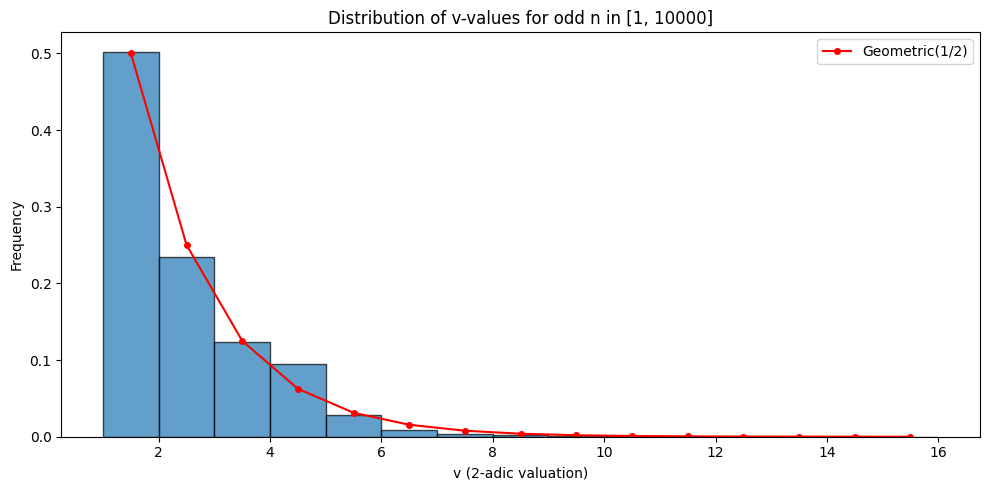

In [4]:
plot_v_sequence_histogram(1, 10_000)
plt.tight_layout()
plt.show()

## Average shrinkage per Syracuse step

Heuristic: each Syracuse step multiplies by 3 and divides by 2^v where E[v] ~ 2. So average factor ~ 3/4 per step — trajectories shrink on average. Let's measure.

In [5]:
ratios = []
for n in range(3, 50_001, 2):
    syr = syracuse(n)
    for i in range(len(syr) - 1):
        ratios.append(syr[i + 1] / syr[i])

ratios = np.array(ratios)
print(f"Geometric mean of Syracuse step ratio: {np.exp(np.mean(np.log(ratios))):.6f}")
print(f"Theoretical 3/4 = {3 / 4:.6f}")
print(f"log2(3)/2 = {np.log2(3) / 2:.6f}")

Geometric mean of Syracuse step ratio: 0.758541
Theoretical 3/4 = 0.750000
log2(3)/2 = 0.792481
